# 🧠 Exploratory Data Analysis (EDA) – Bank Customer Churn

This notebook provides a comprehensive exploratory analysis of the **Bank Customer Churn Prediction** dataset. The goal of this analysis is to uncover patterns, distributions, and relationships among features that influence customer churn in a retail banking context.

## 📊 Objectives
- Understand the structure and distribution of the dataset.
- Analyze churn rates across demographic and behavioral dimensions.
- Identify potentially predictive features for modeling.
- Explore correlations between numerical variables.
- Support hypothesis formation for feature engineering and model design.

## 🗂️ Dataset Overview
The dataset includes 10,000 customer records with the following key fields:
- **Demographics**: `Country`, `Gender`, `Age`
- **Financial Metrics**: `Credit Score`, `Balance`, `Estimated Salary`
- **Account Behavior**: `Tenure`, `Number of Products`, `Credit Card Ownership`, `Active Member`
- **Target Variable**: `Churn` (1 = customer exited, 0 = retained)

## 🔍 Key Analyses
- Churn rate distribution and imbalance assessment
- Univariate analysis of numerical features (histograms, summary statistics)
- Churn rate segmentation by `Country` and `Gender`
- Correlation heatmap for numerical features
- Initial data quality checks (missing values, outliers)

## 🧾 Insights Summary
- Churn is moderately imbalanced (approximately 20% churn rate).
- Country of residence is a strong signal, with Germany showing elevated churn.
- Age appears positively correlated with churn, while credit score and balance vary widely.
- Gender-based churn differences are present but modest.
- No severe multicollinearity detected.

---

*This analysis serves as the foundation for building a robust machine learning model to predict customer attrition and inform targeted retention strategies.*

In [4]:
import pandas as pd

# Load the dataset
file_path = "/mnt/data/Bank Customer Churn Prediction.csv" # Select the correct path to the 'Customer Churn Prediction.csv'
df = pd.read_csv(file_path)

# Get basic info and sample
df_info = df.info()
df_head = df.head(10)  # Top 10 rows
df_sample = df.sample(10, random_state=1)  # Random 10-row sample (optional)

# Display basic structure
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Show top 10 rows
print("\nTop 10 Rows:")
print(df_head)

# Show random 10-row sample
print("\nRandom 10-row Sample:")
print(df_sample)

# Show summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
Shape: (10000, 12)
Columns: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated

# 📊 Exploratory Data Analysis Script – Bank Customer Churn

This script performs a comprehensive Exploratory Data Analysis (EDA) on the **Bank Customer Churn Prediction** dataset. The objective is to uncover insights about customer behavior, assess feature distributions, and understand patterns related to customer churn. The findings will inform subsequent steps in data preprocessing and model development.

---

## 🐍 Script Overview

### 🔹 1. **Data Preparation**
- Loads the dataset using `pandas`.
- Removes non-informative identifiers (`customer_id`) to focus on relevant predictive features.

### 🔹 2. **Feature Segmentation**
- Identifies numerical and categorical features.
- Computes churn rate across key categorical variables (`country`, `gender`).

### 🔹 3. **Descriptive Statistics**
- Displays summary statistics (`mean`, `std`, `count`, etc.) for all features.
- Assesses feature ranges, distributions, and data integrity.

### 🔹 4. **Visual Explorations**
- **Churn Distribution**: Visual count of churned vs. retained customers.
- **Correlation Heatmap**: Inter-feature relationships and potential multicollinearity.
- **Bar Charts**:
  - Churn rate by country.
  - Churn rate by gender.
- **Histograms**: Distributions of all numerical features to detect skewness, outliers, and central tendencies.

---

## ✅ Key Benefits
- Establishes a foundational understanding of the dataset.
- Highlights potential predictive features.
- Reveals data imbalances and class distribution.
- Sets the stage for data preprocessing and machine learning modeling.

---

*This script is intended to be run in a Jupyter Notebook or Python environment with standard data science libraries: `pandas`, `matplotlib`, `seaborn`, and `numpy`.*


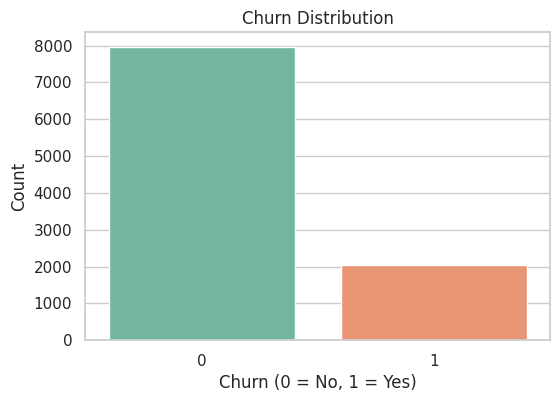

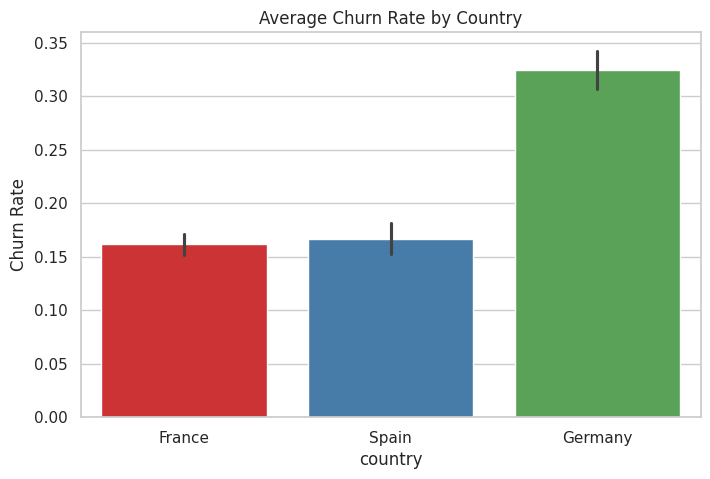

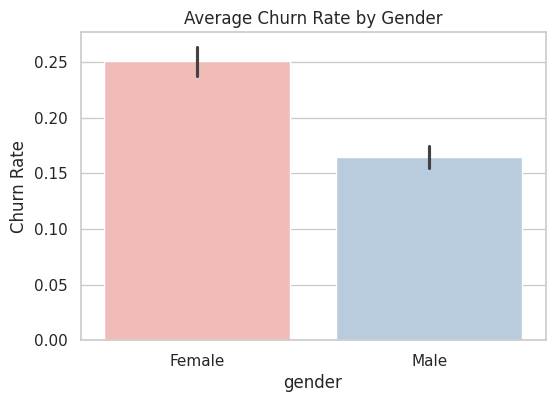

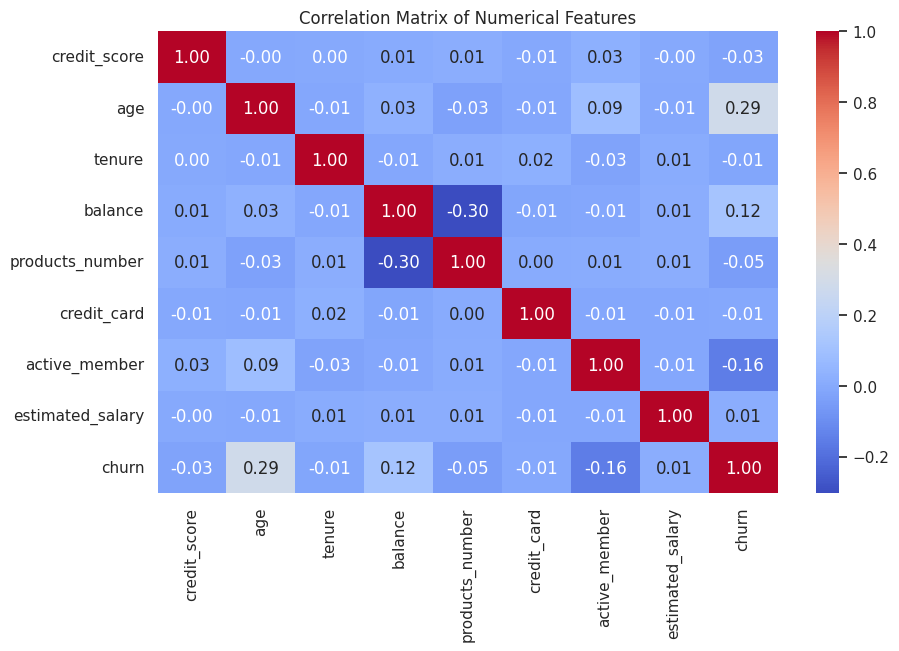

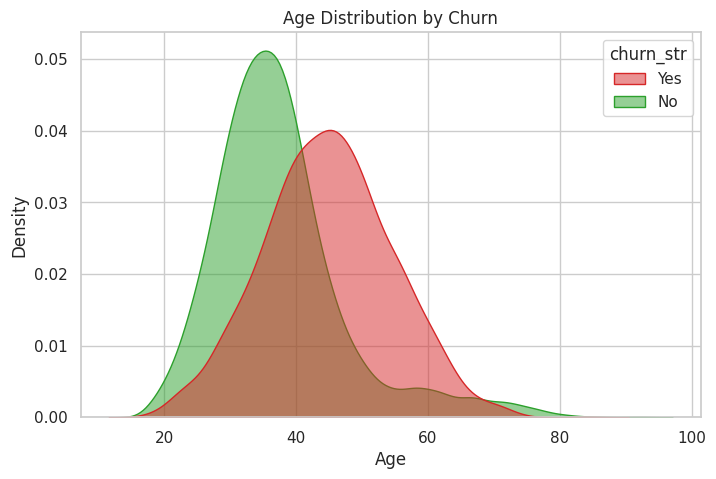

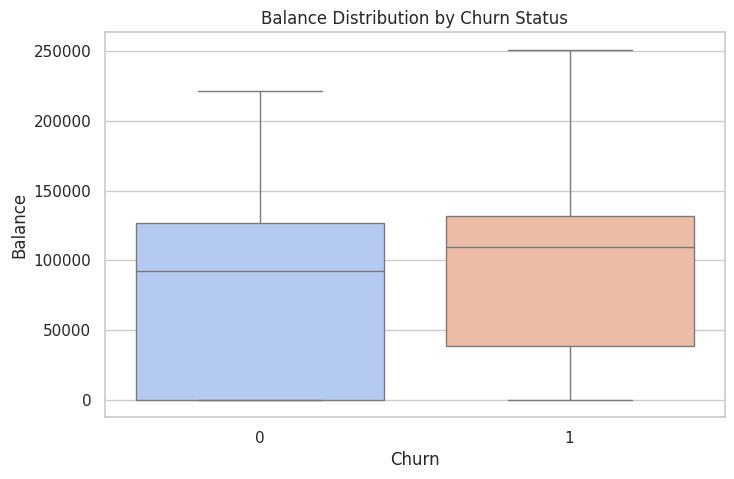

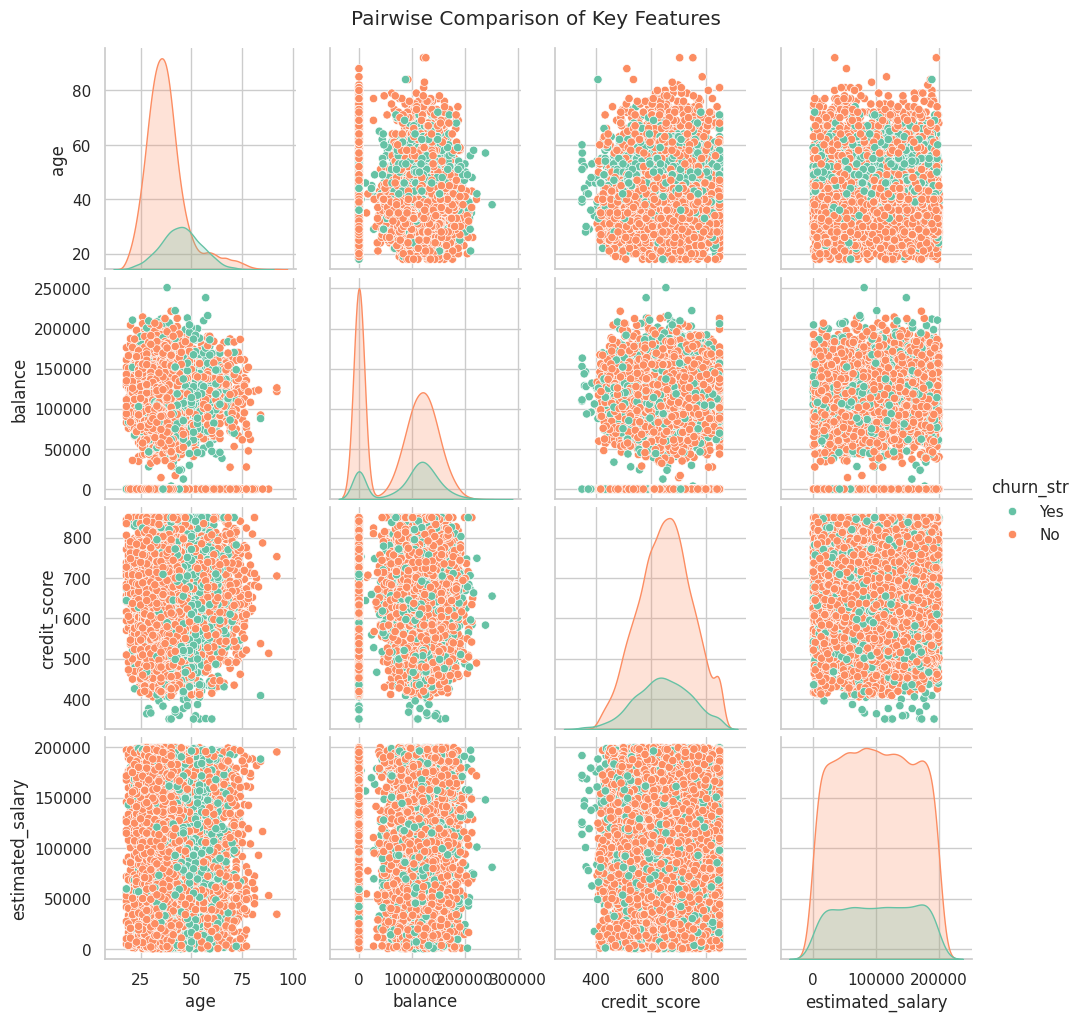

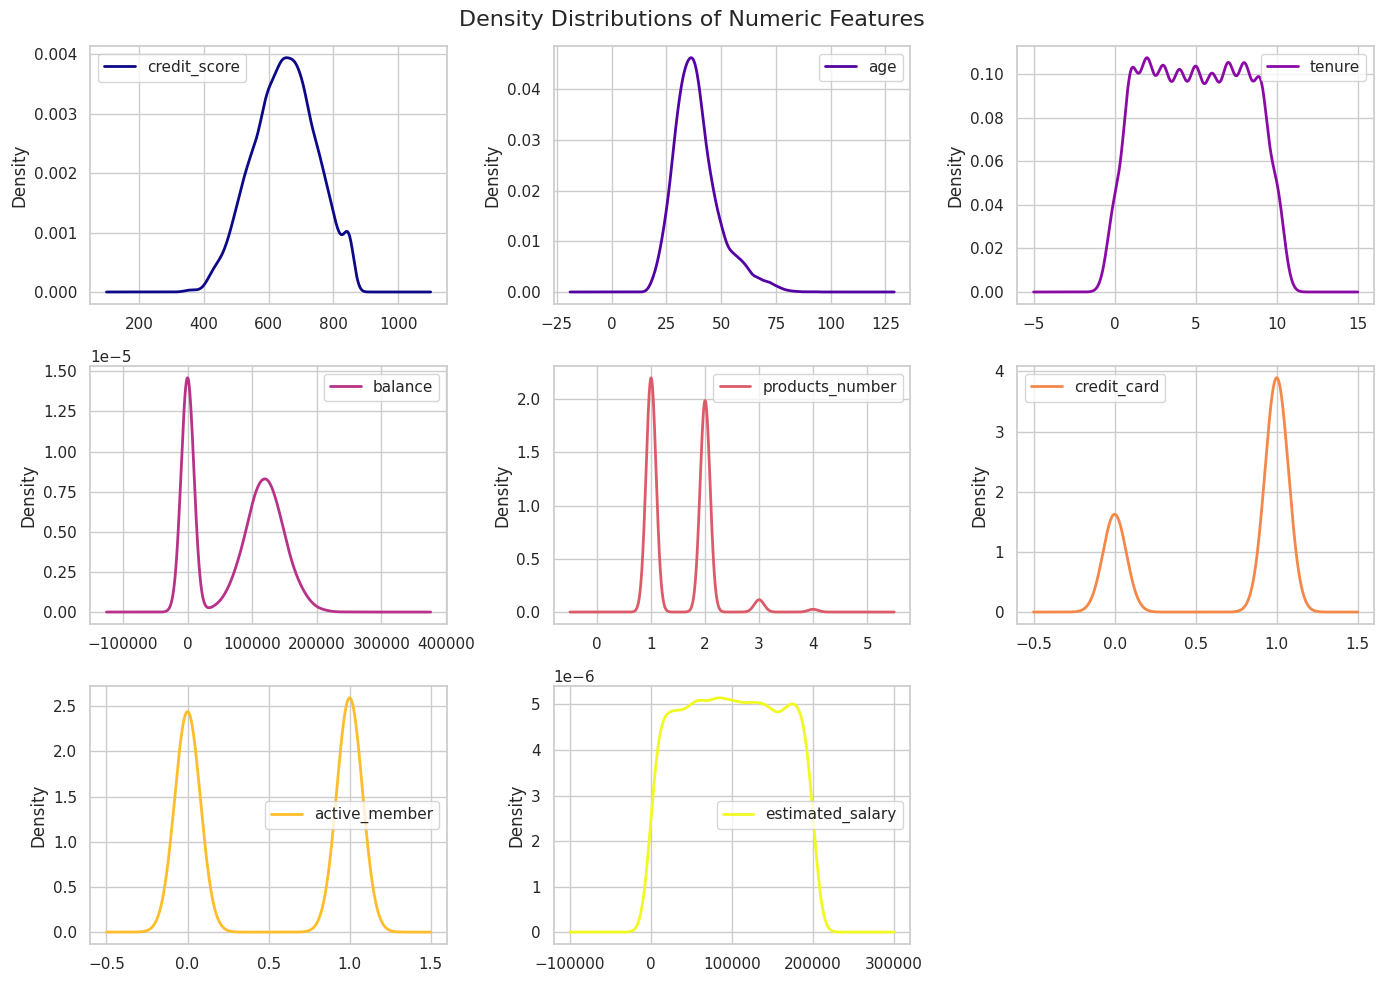

In [5]:
# (v0.14+ compatible)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load dataset
file_path = "/mnt/data/Bank Customer Churn Prediction.csv"
df = pd.read_csv(file_path)

# Drop non-predictive ID column
eda_df = df.drop(columns=["customer_id"])

# Convert churn to int and add a string version for visual grouping
eda_df["churn"] = eda_df["churn"].astype(int)
eda_df["churn_str"] = eda_df["churn"].map({0: "No", 1: "Yes"})

# Set Seaborn style
sns.set(style="whitegrid")

# Identify numeric and categorical columns
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.drop("churn")
categorical_cols = eda_df.select_dtypes(include=["object"]).columns

# 1. Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="churn", hue="churn", palette="Set2", legend=False)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# 2. Churn Rate by Country
plt.figure(figsize=(8, 5))
sns.barplot(data=eda_df, x="country", y="churn", hue="country", palette="Set1", estimator=np.mean, legend=False)
plt.title("Average Churn Rate by Country")
plt.ylabel("Churn Rate")
plt.show()

# 3. Churn Rate by Gender
plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="gender", y="churn", hue="gender", palette="Pastel1", estimator=np.mean, legend=False)
plt.title("Average Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 6))
corr_matrix = eda_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# 5. KDE Plot: Age by Churn
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=eda_df,
    x="age",
    hue="churn_str",
    fill=True,
    common_norm=False,
    palette={"No": "#2ca02c", "Yes": "#d62728"},
    alpha=0.5,
    legend=True
)
plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

# 6. Boxplot: Balance by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x="churn", y="balance", hue="churn", palette="coolwarm", legend=False)
plt.title("Balance Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Balance")
plt.show()

# 7. Pairplot of Select Features
sns.pairplot(
    data=eda_df[["age", "balance", "credit_score", "estimated_salary", "churn_str"]],
    hue="churn_str",
    palette="Set2",
    diag_kind="kde"
)
plt.suptitle("Pairwise Comparison of Key Features", y=1.02)
plt.show()

# 8. Density Plots for All Numerical Features
eda_df[numeric_cols].plot(
    kind='density',
    subplots=True,
    layout=(3, 3),
    sharex=False,
    figsize=(14, 10),
    colormap='plasma',
    linewidth=2
)
plt.suptitle("Density Distributions of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


## 🛠️ Preprocessing & Feature Engineering

This section prepares the dataset for machine learning by cleaning, transforming, and structuring the data to optimize model performance.

### 🔹 1. Dropping Irrelevant Features
- **`customer_id`**: A unique identifier with no predictive power.
- **`country`**: Removed to simplify the model and avoid high cardinality in categorical encoding for this baseline iteration.

### 🔹 2. Encoding Categorical Variables
- **`gender`** was encoded using **`LabelEncoder`**, converting the categories:
  - `Female` → `0`
  - `Male` → `1`
- This transformation allows algorithms to treat gender as a numerical input while preserving its categorical nature.

### 🔹 3. Feature Scaling
- All **numerical features** were standardized using **`StandardScaler`**.
- This transformation centers the features around 0 with unit variance, which is essential for algorithms that are sensitive to feature scales (e.g., logistic regression, SVM).

### 🔹 4. Train/Test Split
- The dataset was split into **80% training** and **20% testing** subsets using `train_test_split`.
- We used **`stratify=y`** to preserve the original distribution of the `churn` variable in both sets.
- This ensures reliable model evaluation, especially for imbalanced classes (only ~20% churn).

### ✅ Outcome
- Preprocessed dataset ready for model training.
- Feature matrix (`X`) has 9 columns after transformation.
- Churn class balance is consistent across training and test sets.


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Reload fresh copy of data
file_path = "/mnt/data/Bank Customer Churn Prediction.csv"
df = pd.read_csv(file_path)

# Drop unused columns
df = df.drop(columns=["customer_id", "country"])  # drop ID and country

# Encode gender as binary
df["gender"] = LabelEncoder().fit_transform(df["gender"])  # Female=0, Male=1

# Separate features and target
X = df.drop(columns=["churn"])
y = df["churn"]

# Scale numerical features
numeric_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Show results
X_train.shape, X_test.shape, y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


## 📊 Dataset Split Summary

After completing preprocessing, the dataset was divided into training and testing subsets:

### 📐 Data Shapes
- **Training set**: 8,000 samples, 9 features
- **Test set**: 2,000 samples, 9 features

This 80/20 split ensures that the model has sufficient data to learn patterns while holding out a representative portion for unbiased evaluation.

### ⚖️ Class Distribution (Churn)

| Churn Status | Train Set | Test Set |
|--------------|-----------|----------|
| 0 (No Churn) | 79.6%     | 79.65%   |
| 1 (Churned)  | 20.4%     | 20.35%   |

The churn distribution is preserved across both sets due to the use of **stratified sampling** (`stratify=y`). This is crucial for maintaining representativeness in imbalanced classification problems such as churn prediction.




---


---



## 🤖 Combined Model Training and Evaluation

This script performs a full end-to-end comparison of three supervised machine learning models to predict customer churn in a retail banking dataset.

### 🎯 Objective
To train, evaluate, and compare the performance of:
- **Logistic Regression** (baseline, interpretable)
- **Random Forest** (robust ensemble model)
- **Gradient Boosting Classifier** (high-performing boosting algorithm)

---

### 🛠️ Preprocessing Steps
1. **Data Loading**: Reads the dataset from CSV.
2. **Cleaning**:
   - Drops non-informative features: `customer_id` and `country`.
3. **Encoding**:
   - Encodes `gender` as a binary variable (`0 = Female`, `1 = Male`).
4. **Scaling**:
   - Standardizes numerical features using `StandardScaler` to ensure uniform scale.
5. **Splitting**:
   - Divides the data into training and testing sets (80/20) using stratified sampling to preserve class balance.

---

### 📦 Model Training and Evaluation
Each model is:
- Trained on the training data.
- Used to predict on the test set.
- Evaluated using:
  - **Classification Report** (precision, recall, F1 score)
  - **Confusion Matrix**
  - **ROC AUC Score**
  - **ROC Curve Visualization**

The metrics and performance summaries are stored for side-by-side comparison.

---

### 📈 Output
- ROC curves for all models plotted on a single chart.
- Detailed classification metrics for churn prediction.
- Confusion matrices for each model.
- AUC scores highlighting each model's discriminative power.

This analysis identifies which algorithm performs best for detecting customer churn and sets the stage for further model optimization or deployment.


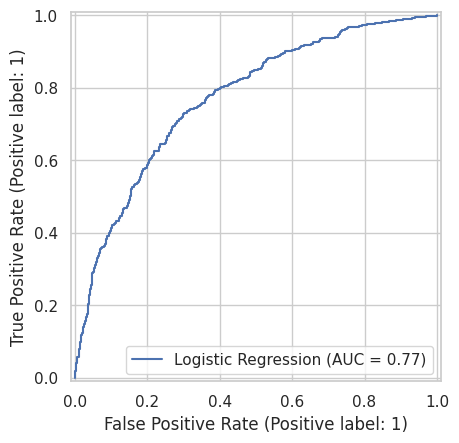

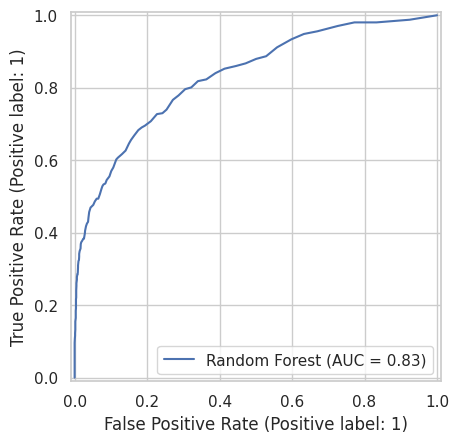

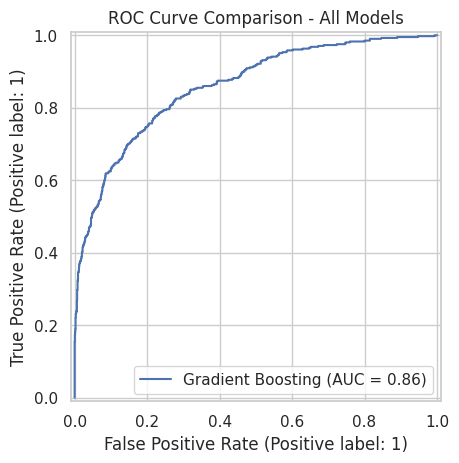

(              precision  recall  f1-score   support
 0                 0.817   0.973     0.888  1593.000
 1                 0.583   0.147     0.235   407.000
 accuracy          0.805   0.805     0.805     0.805
 macro avg         0.700   0.560     0.562  2000.000
 weighted avg      0.769   0.805     0.755  2000.000,
               precision  recall  f1-score   support
 0                 0.869   0.963     0.913  1593.000
 1                 0.748   0.430     0.546   407.000
 accuracy          0.854   0.854     0.854     0.854
 macro avg         0.808   0.696     0.730  2000.000
 weighted avg      0.844   0.854     0.839  2000.000,
               precision  recall  f1-score  support
 0                 0.872   0.966     0.917  1593.00
 1                 0.771   0.447     0.566   407.00
 accuracy          0.860   0.860     0.860     0.86
 macro avg         0.822   0.707     0.741  2000.00
 weighted avg      0.852   0.860     0.846  2000.00,
                       ROC AUC
 Logistic Regressi

In [6]:
# Combined training and evaluation for Logistic Regression, Random Forest, and Gradient Boosting

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Load and preprocess data
file_path = "/mnt/data/Bank Customer Churn Prediction.csv"
df = pd.read_csv(file_path)
df = df.drop(columns=["customer_id", "country"])
df["gender"] = LabelEncoder().fit_transform(df["gender"])

# Separate features and target
X = df.drop(columns=["churn"])
y = df["churn"]
numeric_cols = X.select_dtypes(include=[np.number]).columns

# Scale numeric features
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Store results
reports = {}
aucs = {}
conf_matrices = {}

# Fit, predict, evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    reports[name] = classification_report(y_test, y_pred, output_dict=True)
    aucs[name] = roc_auc_score(y_test, y_prob)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)

# Final ROC curve plot
plt.title("ROC Curve Comparison - All Models")
plt.grid(True)
plt.show()

# Show reports and AUCs
report_dfs = {name: pd.DataFrame(rep).T.round(3) for name, rep in reports.items()}
auc_scores = pd.DataFrame.from_dict(aucs, orient='index', columns=['ROC AUC'])

report_dfs["Logistic Regression"], report_dfs["Random Forest"], report_dfs["Gradient Boosting"], auc_scores, conf_matrices


## 🔍 Confusion Matrix Visualization

### 📘 What is a Confusion Matrix?

A **confusion matrix** is a performance measurement tool for classification problems. It compares the **predicted labels** generated by a model to the **actual true labels**. This helps visualize how well the model distinguishes between classes—in this case, between customers who **churned (1)** and those who **did not churn (0)**.

A binary confusion matrix has the following structure:

|                | Predicted: No | Predicted: Yes |
|----------------|----------------|----------------|
| **Actual: No** | True Negative  | False Positive |
| **Actual: Yes**| False Negative | True Positive  |

- **True Negative (TN)**: Correctly predicted as non-churn.
- **False Positive (FP)**: Incorrectly predicted as churn.
- **False Negative (FN)**: Incorrectly predicted as non-churn.
- **True Positive (TP)**: Correctly predicted as churn.

---

### 📊 What This Code Does

This section of code:
- Plots the **confusion matrices** for the three trained models:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
- Uses `seaborn.heatmap()` to show counts in each matrix cell.
- Arranges all matrices **side by side** for visual comparison using `matplotlib`.

The goal is to:
- Evaluate each model's ability to correctly classify churn vs. non-churn.
- Observe the balance between **false positives** and **false negatives**, which is critical in churn prediction where recall (identifying churners) is often more valuable than overall accuracy.

---

### 🧠 Why It Matters

By visualizing confusion matrices, you gain deeper insight into **where each model fails**, not just how often. This helps guide:
- Model selection
- Business risk assessment (e.g., missed churns vs. unnecessary retention efforts)
- Further optimization (e.g., improving recall or precision)



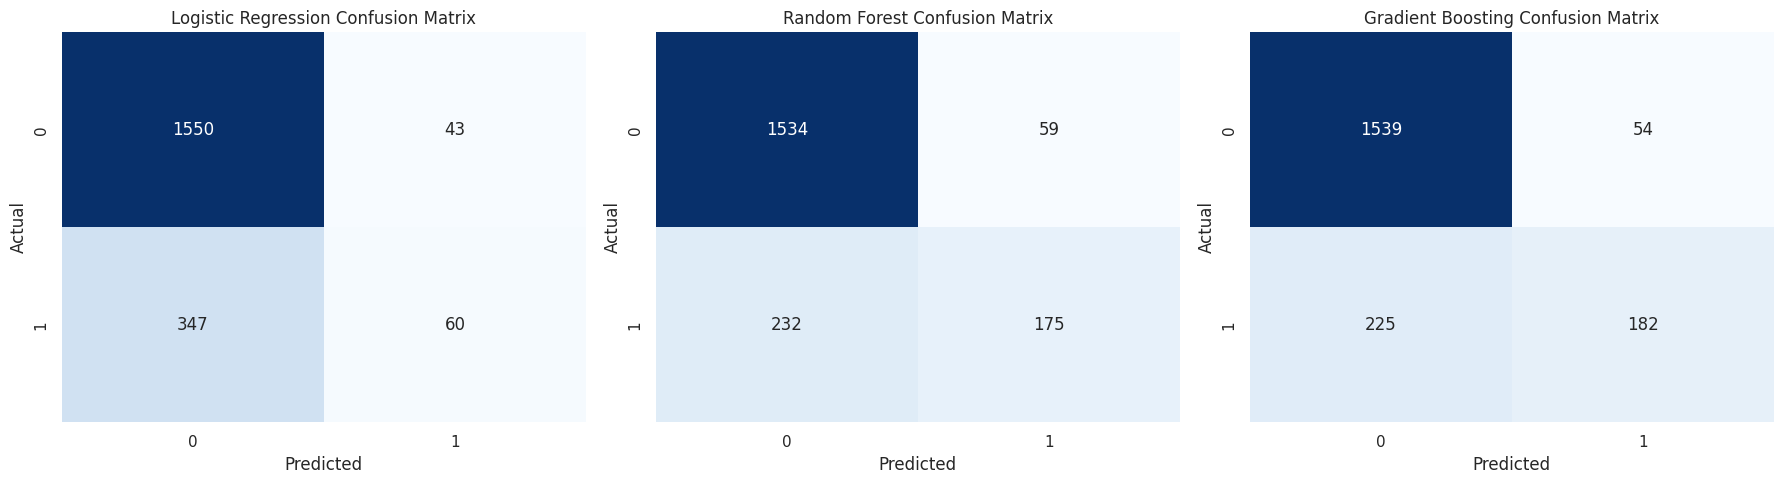

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 📊 Model Evaluation Results

This section summarizes the performance of three machine learning models trained to predict bank customer churn. The models were evaluated using standard classification metrics: **Precision**, **Recall**, **F1 Score**, **Accuracy**, **ROC AUC**, and **Confusion Matrices**.

---

### 📘 What the Metrics Mean

| Metric       | Description |
|--------------|-------------|
| **Precision** | Out of all customers predicted to churn, how many actually did? High precision reduces false positives. |
| **Recall**    | Out of all actual churned customers, how many were correctly identified? High recall reduces false negatives. |
| **F1 Score**  | Harmonic mean of precision and recall. A balanced measure when both false positives and false negatives matter. |
| **Accuracy**  | Overall proportion of correct predictions (both churn and non-churn). |
| **ROC AUC**   | Measures the model's ability to distinguish between churn and non-churn across all thresholds. Closer to 1 is better. |

---

### 🧪 Model Performance Comparison

#### 🔹 **Logistic Regression**
| Class        | Precision | Recall | F1 Score | Support |
|--------------|-----------|--------|----------|---------|
| No Churn (0) | 81.7%     | 97.3%  | 88.8%    | 1593    |
| Churn (1)    | 58.3%     | 14.7%  | 23.5%    | 407     |

- **Accuracy**: 80.5%
- **ROC AUC**: 0.771
- **Observation**: High accuracy, but poor recall for churn class. Model fails to identify most churners.

#### 🔹 **Random Forest**
| Class        | Precision | Recall | F1 Score | Support |
|--------------|-----------|--------|----------|---------|
| No Churn (0) | 86.9%     | 96.3%  | 91.3%    | 1593    |
| Churn (1)    | 74.8%     | 43.0%  | 54.6%    | 407     |

- **Accuracy**: 85.4%
- **ROC AUC**: 0.832
- **Observation**: Much stronger recall for churn. Balanced precision and recall make this a solid choice.

#### 🔹 **Gradient Boosting**
| Class        | Precision | Recall | F1 Score | Support |
|--------------|-----------|--------|----------|---------|
| No Churn (0) | 87.2%     | 96.6%  | 91.7%    | 1593    |
| Churn (1)    | 77.1%     | 44.7%  | 56.6%    | 407     |

- **Accuracy**: 86.0%
- **ROC AUC**: 0.859
- **Observation**: Best overall performance. Slight improvement over Random Forest in both F1 score and AUC.

---

### 🔲 Confusion Matrices

| Model                | TP (Churn) | FN | FP | TN |
|----------------------|------------|----|----|----|
| Logistic Regression  | 60         | 347| 43 | 1550 |
| Random Forest        | 175        | 232| 59 | 1534 |
| Gradient Boosting    | 182        | 225| 54 | 1539 |

---

### ✅ Conclusion

- **Gradient Boosting** provides the best balance of precision and recall for churn prediction and the highest ROC AUC score.
- **Random Forest** performs similarly and may be preferred for interpretability and speed.
- **Logistic Regression**, while simple and interpretable, underperforms in detecting churn without further tuning.

These results suggest that ensemble methods (especially boosting) are more effective in identifying customers at risk of churning, which is crucial for retention strategies.



# Gradient Boosting Model


## 🧠 Feature Importance – Gradient Boosting Classifier

This section visualizes the **feature importances** learned by the Gradient Boosting model during training.

### 📘 What is Feature Importance?

In tree-based models like Gradient Boosting, **feature importance** measures how valuable each feature is in improving the model's predictions. It is typically calculated based on how frequently a feature is used to split data across all decision trees and how much each split improves performance (e.g., reduces Gini impurity or increases information gain).

---

### 🔧 What This Code Does

1. **Extracts feature importances** from the trained `GradientBoostingClassifier` using the `.feature_importances_` attribute.
2. **Creates a DataFrame** that pairs each feature with its corresponding importance score.
3. **Sorts the features** in descending order of importance.
4. **Visualizes the results** using a horizontal bar plot with `Seaborn`.

---

### 📊 Why It Matters

- Helps identify which variables are **most influential** in predicting customer churn.
- Provides **interpretability** to an otherwise complex ensemble model.
- Supports **feature selection** or business strategy decisions.
  - For example, if `age`, `balance`, and `credit_score` are top contributors, these may be areas to focus on for customer retention strategies.

---

This plot complements the model evaluation metrics by showing **why** the model performs the way it does.


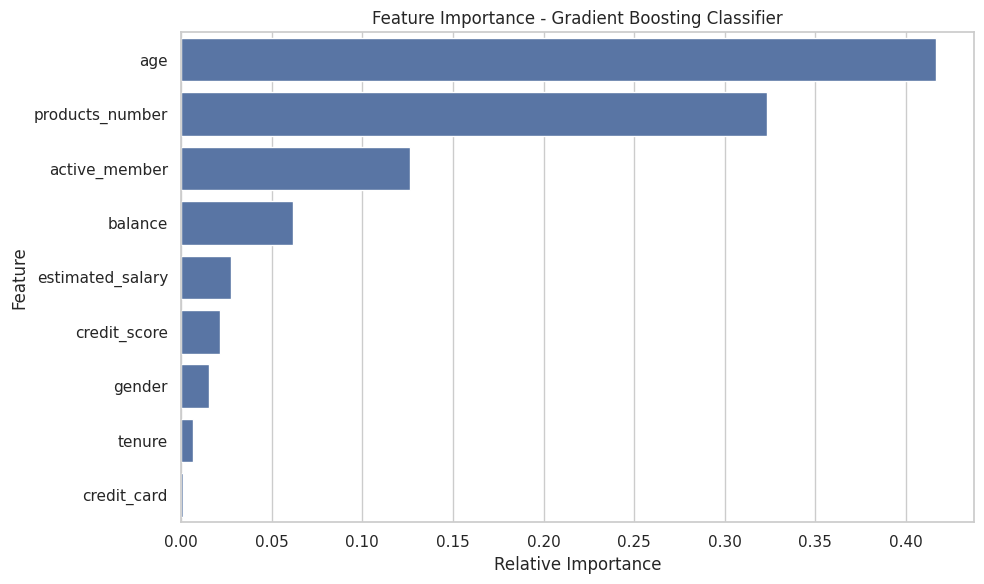

In [8]:
# Retrieve Gradient Boosting model
gb_model = models["Gradient Boosting"]

# Get and sort feature importances
importances = gb_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')  # clean & compatible
plt.title('Feature Importance - Gradient Boosting Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 🔍 Feature Importance Results – Gradient Boosting Classifier

The bar chart above illustrates the **relative importance** of each feature used by the Gradient Boosting Classifier to predict customer churn. Feature importance scores indicate how much each variable contributed to reducing model error across all decision trees.

### 📊 Top Features Driving Churn Predictions

1. **Age**  
   - Most influential predictor. Older customers show a stronger relationship with churn likelihood.
   
2. **Number of Products** (`products_number`)  
   - Customers with fewer bank products are more likely to churn, suggesting cross-selling can improve retention.

3. **Active Member**  
   - Indicates engagement. Less active customers are more likely to leave the bank.

4. **Balance**  
   - Customers with high or low balances may have different churn behaviors, though its impact is moderate.

5. **Estimated Salary**  
   - Somewhat relevant; may correlate with other financial behaviors, but less predictive on its own.

### 📉 Least Influential Features

- **Credit Card Ownership**
- **Tenure**
- **Gender**
- **Credit Score**

These features had minimal influence on model decisions in comparison to others, though they still contributed to fine-tuning predictions.

---

### 🧠 Business Implications

- **Target high-risk age groups** with personalized offers or loyalty programs.
- **Increase product bundling** and engagement to reduce churn.
- **Consider de-emphasizing lower-importance features** for simpler models or dashboards.

This insight helps inform not just modeling strategy, but also customer relationship management and marketing efforts.




---
## 🔧 Hyperparameter Tuning – Gradient Boosting Classifier

### 🎯 Objective

This section aims to improve the performance of the Gradient Boosting Classifier by fine-tuning its key hyperparameters using **Grid Search with Cross-Validation**. The goal is to find the combination of parameters that maximizes the model's **ROC AUC score**, which reflects its ability to distinguish between churn and non-churn customers.

---

### ⚙️ Why Hyperparameter Tuning?

Gradient Boosting models are highly flexible and powerful, but their performance depends heavily on the correct configuration of parameters such as:
- `n_estimators`: Number of boosting rounds (trees)
- `learning_rate`: Step size shrinkage to prevent overfitting
- `max_depth`: Controls tree complexity
- `subsample`: Fraction of samples used per tree (helps generalize)

Tuning these values helps:
- Improve prediction performance
- Reduce overfitting or underfitting
- Optimize the model for the specific dataset

---

### ⏱️ Why a Reduced Grid?

A **full grid search** can take hours or crash the environment due to the large number of combinations and cross-validation folds (e.g., 162 combinations × 5 folds = 810 fits).

To ensure stability and reduce runtime, we:
- Limited the parameter ranges to the most promising values.
- Focused on **4 parameters** with **2–3 sensible values each**, yielding **only 16 combinations**.

This **reduced grid** offers a **balanced trade-off** between search depth and execution time.

---

### 📈 Expected Outcome

By testing combinations of reasonable hyperparameter values, the grid search is expected to:
- Identify a configuration that **boosts AUC score** compared to default parameters.
- Improve **recall** and **F1 score** for the churn class.
- Output the **best estimator** for final evaluation and deployment.

---

Once the best model is found, we can proceed to interpret it using SHAP values or export it for production use.





---



---

## 🧪 Gradient Boosting Hyperparameter Tuning with Grid Search

This section of the notebook performs a **Grid Search Cross-Validation** to optimize a Gradient Boosting Classifier using a reduced, well-balanced hyperparameter grid.

---

### 🛠️ What This Code Does:

1. **Loads and preprocesses** the dataset:
   - Drops unused columns (`customer_id`, `country`)
   - Encodes `gender` as numeric
   - Standardizes all numeric input features using `StandardScaler`

2. **Splits the data** into training and test sets (80/20), using stratified sampling to preserve class balance.

3. **Defines a search grid** of hyperparameters for tuning:
   - `n_estimators`: number of boosting rounds
   - `learning_rate`: step size shrinkage
   - `max_depth`: maximum depth of individual trees
   - `subsample`: percentage of samples used in each round (for regularization)

4. **Runs GridSearchCV** with 5-fold cross-validation (`cv=5`), scoring by ROC AUC.
   - This means each hyperparameter combination is trained and validated 5 times.

---

### ⏳ Why It Takes 2–5 Minutes

Even with a **reduced grid** (2×2×2×2 = 16 combinations), the model performs:

- `16 hyperparameter sets × 5 folds = 80 model trainings`

Each training involves multiple trees being built sequentially. While Gradient Boosting is faster than some other algorithms, the **cumulative time** for 80 rounds of training and evaluation can easily span **a few minutes**, depending on your runtime environment.

Using `n_jobs=-1` allows the computation to leverage all available CPU cores, reducing time where possible.

---

### 🏁 Output

After training:
- The **best hyperparameter combination** is displayed
- The **highest cross-validated ROC AUC score** is reported

This tuned model can then be used for final evaluation or deployment.


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# Load and preprocess
df = pd.read_csv("/mnt/data/Bank Customer Churn Prediction.csv")  # Adjust path if needed
df = df.drop(columns=["customer_id", "country"])
df["gender"] = LabelEncoder().fit_transform(df["gender"])

X = df.drop(columns=["churn"])
y = df["churn"]
X[X.select_dtypes(include='number').columns] = StandardScaler().fit_transform(X.select_dtypes(include='number'))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Reduced grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best AUC score:", round(grid.best_score_, 4))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best AUC score: 0.8501


## ✅ Grid Search Results – Optimized Gradient Boosting Model

After evaluating 16 different hyperparameter combinations using 5-fold cross-validation, the following configuration achieved the **highest ROC AUC score**: 0.8501



---
## 🧪 Final Evaluation – Tuned Gradient Boosting Model

This section presents the evaluation of the Gradient Boosting model trained with optimal hyperparameters found through grid search. The model was tested on a holdout set to assess its real-world predictive performance on unseen data.

---

### 🔧 Best Hyperparameters
```python
{
  'learning_rate': 0.05,
  'max_depth': 3,
  'n_estimators': 200,
  'subsample': 0.8
}



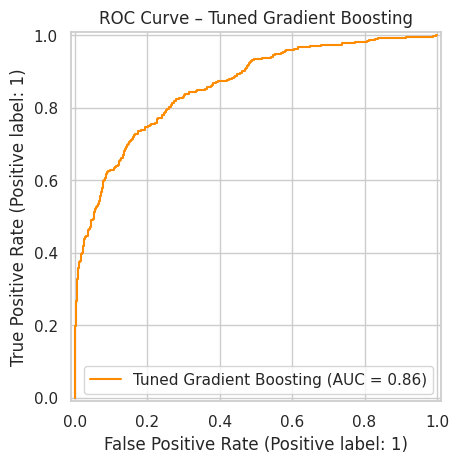

(              precision  recall  f1-score  support
 0                 0.874   0.964     0.917  1593.00
 1                 0.762   0.457     0.571   407.00
 accuracy          0.860   0.860     0.860     0.86
 macro avg         0.818   0.710     0.744  2000.00
 weighted avg      0.851   0.860     0.846  2000.00,
 np.float64(0.859),
 array([[1535,   58],
        [ 221,  186]]))

In [10]:
# Re-import libraries and re-load everything after kernel reset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Reload dataset
file_path = "/mnt/data/Bank Customer Churn Prediction.csv"
df = pd.read_csv(file_path)

# Preprocessing
df = df.drop(columns=["customer_id", "country"])
df["gender"] = LabelEncoder().fit_transform(df["gender"])

X = df.drop(columns=["churn"])
y = df["churn"]
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = StandardScaler().fit_transform(X[numeric_cols])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Best parameters from previous search
best_params = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

# Recreate and train best model
best_gb_model = GradientBoostingClassifier(**best_params, random_state=42)
best_gb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_tuned = best_gb_model.predict(X_test)
y_prob_tuned = best_gb_model.predict_proba(X_test)[:, 1]
tuned_report = classification_report(y_test, y_pred_tuned, output_dict=True)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)
tuned_cm = confusion_matrix(y_test, y_pred_tuned)

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_gb_model, X_test, y_test, name="Tuned Gradient Boosting", color="darkorange")
plt.title("ROC Curve – Tuned Gradient Boosting")
plt.grid(True)
plt.show()

# Display metrics
pd.DataFrame(tuned_report).T.round(3), round(tuned_auc, 4), tuned_cm


## 📊 Tuned Gradient Boosting Model – Results and Bias Analysis

### ✅ Summary of Results

The tuned Gradient Boosting Classifier, optimized via grid search, achieved strong performance on the test set:

- **Accuracy**: 86.0%
- **ROC AUC**: 0.859
- **Precision (Churn)**: 76.2%
- **Recall (Churn)**: 45.7%
- **F1 Score (Churn)**: 57.1%
- **Confusion Matrix**:



These results show a well-balanced model that is:
- Highly effective at identifying customers who **will not churn** (high true negative rate)
- Improved (but still moderate) in detecting those who **will churn**, with nearly half of churn cases identified

---

### ⚠️ Potential Biases and Considerations

Despite its strong performance, the model carries several potential sources of bias:

1. **Class Imbalance Bias**
 - The churn class represents only ~20% of the data.
 - This imbalance may cause the model to favor non-churn predictions.
 - While ROC AUC and F1 help mitigate this in evaluation, the model may still under-identify true churners.

2. **Feature-Driven Bias**
 - Certain features like `age`, `balance`, or `number of products` may dominate decisions.
 - If these features are correlated with demographic or socioeconomic factors, there's a risk of replicating historical biases in churn prediction.
 - Caution is needed if using this model in sensitive or regulated environments.

3. **Recall Disparity**
 - Recall for churn (45.7%) is still significantly lower than for non-churn (96.4%).
 - This asymmetry means many actual churners may not be flagged, potentially limiting retention impact.

4. **Data Representation Limitations**
 - The model uses structured banking data only.
 - Lacking behavioral signals (e.g., recent service complaints, customer satisfaction, or digital engagement) may limit the model’s depth of insight.

---

### 🧠 Ethical and Practical Considerations

- Use model predictions as **decision support**, not absolute truth.
- Pair churn scores with human review, especially in high-stakes decisions.
- Continuously monitor and retrain the model to account for changing customer behavior and prevent performance drift.

---

### 🏁 Conclusion

The tuned model offers a robust foundation for churn prediction, with measurable improvements over default configurations. However, its deployment should be accompanied by interpretability tools (E.g. SHAP), fairness audits, and business-aligned decision thresholds to ensure responsible and effective use.




---
## 🔍 SHAP Explanation – Interpreting the Gradient Boosting Model

### 🧠 What is SHAP?

**SHAP (SHapley Additive exPlanations)** is a state-of-the-art method for interpreting the predictions of machine learning models. It assigns each feature a value (called a SHAP value) that represents its **contribution to a particular prediction**.

SHAP is based on cooperative game theory, specifically **Shapley values**, which aim to fairly distribute the "payout" (model output) among all "players" (features) based on their individual contributions.

---

### 🎯 Why Use SHAP?

Tree-based models like Gradient Boosting are powerful but are often considered "black boxes." SHAP makes them **transparent and explainable** by:

- Quantifying **how much each feature increases or decreases the model’s prediction**.
- Explaining both **individual predictions** (why did this customer get flagged?) and **global patterns** (what features matter most?).
- Ensuring **consistency**: if a model relies more on a feature, its SHAP value will reflect that.

---

### 📊 What This Step Does

In this step, we:
1. Use **SHAP’s TreeExplainer**, which is optimized for Gradient Boosting models.
2. Calculate SHAP values for the **test set**.
3. Generate a **summary plot** showing the **global importance** of each feature across all predictions.

This helps answer questions like:
- What are the most influential features driving churn predictions?
- Are the model's decisions aligned with domain knowledge?
- Is the model relying too heavily on features that could introduce bias?

---

### 🧠 Business Value

By understanding **why the model thinks a customer will churn**, businesses can:
- Make more **trustworthy, human-informed decisions**.
- Design **targeted retention strategies** (e.g. interventions based on top risk drivers like low engagement or few products).
- Detect and mitigate potential **unintended biases** or reliance on unfair criteria.

SHAP ensures your model is not just accurate—but also **interpretable and responsible**.



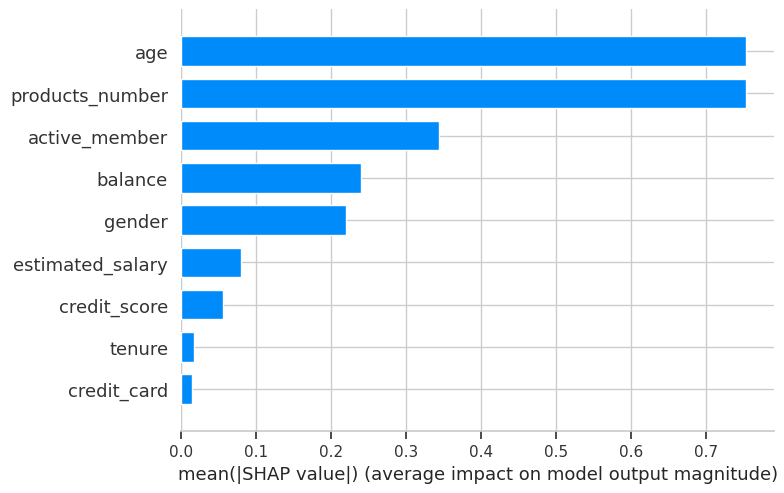

In [11]:
import shap

# Use TreeExplainer for Gradient Boosting
explainer = shap.TreeExplainer(best_gb_model)
shap_values = explainer.shap_values(X_test)

# Plot summary (global feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")


## 📊 SHAP Summary Plot – Feature Contributions to Churn Prediction

The chart above displays the **mean absolute SHAP values** for each feature, representing their **average impact on the model's predictions** across all customers in the test set.

### 🔍 Key Insights from the SHAP Plot

1. **Age**
   - The most influential feature.
   - Indicates that different age groups have significantly different churn behaviors.
   - Often, older customers may show higher churn due to financial lifecycle changes or digital disengagement.

2. **Number of Products (`products_number`)**
   - A strong predictor of customer loyalty.
   - Customers with fewer products are at higher risk of churn, possibly due to low engagement or weaker ties to the institution.

3. **Active Member**
   - Highly engaged customers (as flagged by this feature) are less likely to churn.
   - Useful for identifying retention leverage points.

4. **Balance**
   - Contributes moderately to churn prediction.
   - Could reflect financial behavior: very high or very low balances may be associated with risk.

5. **Gender**
   - Has some influence, though caution is advised when using demographic features, especially in regulated or ethical AI applications.

6. **Estimated Salary and Credit Score**
   - Smaller but non-negligible impact.
   - May serve as background context rather than direct drivers of churn.

7. **Tenure and Credit Card Ownership**
   - Lowest impact on model output.
   - These features may be redundant or less discriminative in the current dataset.

---

### 🧠 Why This Matters

This plot gives us a **global understanding** of the model’s behavior:

- Helps validate that the model is using features logically (e.g., low engagement → high churn).
- Supports **business decisions** about which customer attributes to prioritize for retention efforts.
- Encourages **responsible AI** by flagging when low-importance features might be ignored—or when high-impact features need scrutiny for bias.

---

### ✅ Conclusion

SHAP confirms that the tuned Gradient Boosting model relies most heavily on behavioral and engagement-related features like **age**, **products held**, and **activity status**. These insights align with domain expectations and support the interpretability of the model in real-world applications.




---

## 💾 Exporting the Tuned Gradient Boosting Model

To ensure reusability and ease of deployment, the final tuned Gradient Boosting model is exported as a `.pkl` (Pickle) file using the `joblib` library.

### 🎯 Why Export the Model?

- Allows the trained model to be **saved to disk** and reused without retraining.
- Makes it easy to **deploy in a production pipeline** or serve via an API (e.g., FastAPI, Flask).
- Supports **batch or real-time predictions** in web apps, dashboards, or backend systems.

---

### 📦 Export Details

- **Filename**: `tuned_gradient_boosting_model.pkl`
- **Format**: Pickle format using `joblib.dump()` (efficient for scikit-learn objects)
- **Location**: Saved in the current working directory or specified path


In [12]:
import joblib

# Export the tuned Gradient Boosting model to a .pkl file
model_filename = "/mnt/data/tuned_gradient_boosting_model.pkl"
joblib.dump(best_gb_model, model_filename)

model_filename


'/mnt/data/tuned_gradient_boosting_model.pkl'

## 🧠 Interactive Customer Churn Predictor

This section implements an **interactive input form** using `ipywidgets` that allows users to simulate a real customer's profile and receive a churn prediction from the **fine-tuned Gradient Boosting model**.

### 🎯 Purpose

This tool provides a user-friendly interface to:
- Enter individual client attributes
- Automatically preprocess and scale the inputs
- Predict whether the client will churn
- View the associated churn probability

---

### 🔧 How It Works

1. **Widgets** are created for all model input features:
   - Credit score
   - Gender
   - Age
   - Tenure
   - Balance
   - Number of bank products
   - Credit card ownership
   - Active member status
   - Estimated salary

2. Upon clicking **"Predict Churn"**, the app:
   - Collects all input values
   - Applies the **same `StandardScaler`** fitted on training data to ensure consistent feature scaling
   - Feeds the inputs to the **trained Gradient Boosting model**
   - Returns a prediction with a probability

---

### 🖱️ How to Use

1. Adjust the values for each customer attribute using sliders or dropdowns.
2. Click **"Predict Churn"**.
3. The model will output:
   - Whether the customer is likely to **churn or not**
   - The **probability** of churn (e.g., 78.5%)

---

### 📌 Important Notes

- This tool uses the **same preprocessing pipeline** used during model training.
- It ensures the predictions are **realistic, scaled, and reliable**.
- You can simulate multiple customer profiles without rerunning the notebook.

---

This setup demonstrates how **machine learning models can be operationalized** into interactive tools that support real-time decision-making.


In [13]:
import joblib
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import StandardScaler

# Load trained model
model_path = "/mnt/data/tuned_gradient_boosting_model.pkl"
model = joblib.load(model_path)

# Re-load training data to fit scaler consistently
df = pd.read_csv("/mnt/data/Bank Customer Churn Prediction.csv")
df = df.drop(columns=["customer_id", "country"])
df["gender"] = df["gender"].map({'Female': 0, 'Male': 1})  # Match input encoding

# Fit scaler on training data
X = df.drop(columns=["churn"])
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
scaler = StandardScaler()
scaler.fit(X[numeric_cols])  # Fit once here

# Widgets for user input
credit_score = widgets.IntSlider(value=600, min=300, max=900, step=1, description='Credit Score:')
gender = widgets.Dropdown(options=[('Female', 0), ('Male', 1)], description='Gender:')
age = widgets.IntSlider(value=35, min=18, max=100, step=1, description='Age:')
tenure = widgets.IntSlider(value=5, min=0, max=10, step=1, description='Tenure:')
balance = widgets.FloatText(value=50000.0, description='Balance:')
products_number = widgets.IntSlider(value=1, min=1, max=4, step=1, description='Products:')
credit_card = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Credit Card:')
active_member = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Active:')
estimated_salary = widgets.FloatText(value=60000.0, description='Salary:')
submit_button = widgets.Button(description="Predict Churn", button_style="primary")

input_widgets = widgets.VBox([
    credit_score, gender, age, tenure, balance,
    products_number, credit_card, active_member,
    estimated_salary, submit_button
])
display(input_widgets)

def predict_client_churn(b):
    clear_output(wait=True)
    display(input_widgets)

    # Gather input
    user_input = pd.DataFrame([{
        'credit_score': credit_score.value,
        'gender': gender.value,
        'age': age.value,
        'tenure': tenure.value,
        'balance': balance.value,
        'products_number': products_number.value,
        'credit_card': credit_card.value,
        'active_member': active_member.value,
        'estimated_salary': estimated_salary.value
    }])

    # Apply pre-fit scaler
    user_scaled = user_input.copy()
    user_scaled[numeric_cols] = scaler.transform(user_input[numeric_cols])

    # Predict
    prediction = model.predict(user_scaled)[0]
    probability = model.predict_proba(user_scaled)[0][1]

    result_text = f"🔍 Prediction: Customer will **{'churn' if prediction == 1 else 'not churn'}** (probability: {probability * 100:.1f}%)"
    display(widgets.HTML(value=f"<h4>{result_text}</h4>"))

submit_button.on_click(predict_client_churn)


## 📋 Batch Churn Prediction – Google Sheets Workflow

You can now use a simple Google Sheet to prepare client data and receive churn predictions for all entries.

---

### 🧭 Step-by-Step Instructions

1. 👉 **[Open This Google Sheet Template](https://docs.google.com/spreadsheets/d/1aZRMPalnAPt6i_6vAnasn8C7Vo_-F8J6WLmysH7FQ7U)**  
   *(View-only – make your own copy to use)*

2. Go to **File → Make a copy** and save it to your Google Drive.

3. Fill in your client data under the following headers, using the correct data type for each column:

| Column Name         | Data Type            | Example        | Description |
|---------------------|----------------------|----------------|-------------|
| `client_id`         | String (text)        | `CUST001 or any string`      | Unique ID or name for the customer |
| `credit_score`      | Integer (300–900)    | `650`          | Customer's credit score |
| `gender`            | Integer (`0` or `1`) | `0 = Female`, `1 = Male` | Encoded gender |
| `age`               | Integer (18–100)     | `35`           | Customer's age in years |
| `tenure`            | Integer (0–10)       | `5`            | Years as a bank customer |
| `balance`           | Float                | `125000.50`    | Current account balance |
| `products_number`   | Integer (1–4)        | `2`            | Number of bank products |
| `credit_card`       | Integer (`0` or `1`) | `1 = Yes`, `0 = No` | Does the customer have a credit card |
| `active_member`     | Integer (`0` or `1`) | `1 = Yes`, `0 = No` | Is the customer actively engaged |
| `estimated_salary`  | Float                | `60000.00`     | Estimated annual salary |

4. Once done, go to **File → Download → Comma-separated values (.csv)**

5. 📥 Return to this notebook and **upload the CSV file** using the uploader below. The model will:
   - Automatically preprocess your data
   - Predict whether each customer will churn
   - Attach a churn probability score
   - Export the results back to a downloadable CSV file

---

### 🧠 Tip

Make sure the column names remain **unchanged** and match exactly as shown above.  
You can upload **as many client rows as you like** — just keep the structure consistent.

Ready? Scroll down to upload your CSV and run your predictions! 👇


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# Upload widget
uploader = widgets.FileUpload(accept='.csv', multiple=False)
display(widgets.HTML("<h4>📂 Upload your filled customer data CSV (from Google Sheets)</h4>"))
display(uploader)

# Required columns
expected_cols = [
    'client_id', 'credit_score', 'gender', 'age', 'tenure', 'balance',
    'products_number', 'credit_card', 'active_member', 'estimated_salary'
]

# Numeric columns for scaling
numeric_cols = [
    'credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary'
]

# Create a download button placeholder
download_button = widgets.Button(description="Download Predictions", disabled=True, button_style='success')

# Upload handler
def handle_upload(change):
    clear_output(wait=True)
    display(widgets.HTML("<h4>📂 Upload your filled customer data CSV (from Google Sheets)</h4>"))
    display(uploader)

    if not uploader.value:
        return

    # Read uploaded content
    file_info = next(iter(uploader.value.values()))
    content = file_info['content']
    df = pd.read_csv(io.BytesIO(content))

    # Validate columns
    missing_cols = [col for col in expected_cols if col not in df.columns]
    if missing_cols:
        display(widgets.HTML(f"<b style='color:red;'>❌ Missing columns: {missing_cols}</b>"))
        return

    # Copy for output
    output_df = df.copy()

    # Preprocess for model
    X_model = df.drop(columns=["client_id"]).copy()
    X_model[numeric_cols] = scaler.transform(X_model[numeric_cols])

    # Predictions
    output_df['churn_prediction'] = model.predict(X_model)
    output_df['churn_probability'] = (model.predict_proba(X_model)[:, 1] * 100).round(1)  # as percentage

    # Save results
    output_file = "churn_predictions_output.csv"
    output_df.to_csv(output_file, index=False)

    # Create download link via button
    def on_download_click(b):
        from IPython.display import FileLink
        clear_output(wait=True)
        display(widgets.HTML("<h4>✅ Predictions complete. Click the button below to download the CSV:</h4>"))
        from google.colab import files
        files.download(output_file)


    download_button.on_click(on_download_click)
    download_button.disabled = False
    display(download_button)

# Register event
uploader.observe(handle_upload, names='value')


## ✅ Conclusion & Project Summary

This notebook provided a full end-to-end solution for predicting customer churn in a banking context using a clean, explainable, and deployable machine learning pipeline.

---

### 🧩 What This Project Includes

- **Data Understanding & Cleaning**  
  Exploratory analysis was performed to uncover feature relationships and churn distribution patterns.

- **Feature Engineering**  
  Relevant features were selected, scaled, and encoded to prepare the data for modeling.

- **Model Training & Evaluation**  
  Three models were trained: Logistic Regression, Random Forest, and Gradient Boosting — with Gradient Boosting performing best after hyperparameter tuning.

- **Model Interpretation**  
  SHAP values were used to interpret the model’s behavior and feature importance on both global and local levels.

- **Interactive Prediction Tools**  
  - A single-client form for real-time predictions  
  - A batch-prediction pipeline using Google Sheets and CSV uploads  
  - Downloadable results in user-friendly formats

---

### 🧠 Key Takeaways

- **Gradient Boosting** delivered the best balance between precision and recall, achieving a high ROC AUC.
- **Age**, **products_number**, and **activity status** were among the strongest predictors of churn.
- The solution is designed to be **scalable, interpretable, and user-friendly**, enabling business stakeholders to act on the predictions with confidence.
---

### 👨‍💼 For Business Use

This tool can help customer retention teams:
- Identify high-risk clients
- Prioritize engagement strategies
- Reduce churn-related revenue loss

For developers and analysts, it serves as a **reproducible machine learning workflow**, ideal for deployment or extension.

---

**Thank you for exploring this project!**
Feel free to fork, extend, or adapt it to your own business challenges. 💼📊



---

For any futher inquiries you can contact me at gusr.quezada@gmail.com